# 💍 Marriage Longevity — Complete EDA & Divorce Prediction

> **Dataset**: `marriage_longevity_master.csv` — ~45 000 marriage records  
> **Goal**: Understand factors that drive divorce and build a binary classifier to predict it  
> **Target Variable**: `divorced` (1 = Divorced, 0 = Still Married)

---

## 🗂️ Table of Contents
1. [Environment Setup & Library Imports](#1)
2. [Load Dataset & Initial Inspection](#2)
3. [Exploratory Data Analysis (EDA)](#3)
   - 3.1 Univariate — Numerical
   - 3.2 Univariate — Categorical
   - 3.3 Bivariate vs Target
   - 3.4 Correlation Heatmap
   - 3.5 Gottman Four Horsemen Deep-Dive
4. [Data Preprocessing & Feature Engineering](#4)
5. [Baseline Models](#5)
6. [Advanced Models — XGBoost, LightGBM, CatBoost](#6)
7. [Hyperparameter Tuning (Optuna)](#7)
8. [Model Evaluation & Comparison](#8)
9. [Explainability — SHAP Values](#9)
10. [Conclusions & Key Insights](#10)


---
<a id='1'></a>
## 1. 📦 Environment Setup & Library Imports

Install and import all required libraries for data manipulation, visualization,
machine learning, and model explainability.


In [ ]:
# Install required packages (run once)
# !pip install -q xgboost lightgbm catboost optuna shap scikit-learn pandas numpy matplotlib seaborn plotly


In [11]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from plotly.subplots import make_subplots

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report, RocCurveDisplay, precision_recall_curve
)

import xgboost as xgb
import lightgbm as lgb
import catboost as cb

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import shap

sns.set_theme(style='darkgrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
RANDOM_STATE = 42

print('All libraries imported successfully!')


All libraries imported successfully!


---
<a id='2'></a>
## 2. 📂 Load Dataset & Initial Inspection

Load the raw CSV, inspect shape, dtypes, missing values, and the class distribution.


In [12]:
DATA_PATH = '../Dataset/marriage_longevity_master.csv'
df_raw = pd.read_csv(DATA_PATH)

print(f'Shape: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns')
df_raw.head()


Shape: 45,000 rows x 24 columns


,marriage_id,marriage_number,age_at_marriage,age_gap_years,education_level,household_income_usd,financial_stress,both_employed,cohabited_before,premarital_counseling,...,contempt,defensiveness,stonewalling,repair_attempt_success,positive_negative_ratio,conflict_frequency_weekly,shared_activities_weekly,years_married,years_to_divorce,divorced
0,MAR000000,1,36,6,less_than_hs,68600.0,5.9,1,1,0,...,7.7,5.8,8.1,4.1,2.22,3.0,4.0,22.0,NaN,0
1,MAR000001,2,59,1,some_college,328800.0,0.0,1,1,0,...,1.7,6.8,3.0,5.1,11.99,1.0,1.0,15.5,NaN,0
2,MAR000002,2,44,1,high_school,139900.0,6.1,0,0,1,...,6.5,4.2,4.8,5.7,2.27,4.0,2.0,7.2,NaN,0
3,MAR000003,1,25,2,bachelors,97600.0,5.9,1,1,1,...,0.0,4.1,0.9,8.7,6.24,0.0,4.0,13.5,NaN,0
4,MAR000004,2,29,3,graduate,98200.0,4.0,0,0,1,...,4.4,4.6,9.6,8.9,2.59,4.0,5.0,7.5,7.5,1


In [13]:
df_raw.info()


<class 'pandas.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 24 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   marriage_id                45000 non-null  str    
 1   marriage_number            45000 non-null  int64  
 2   age_at_marriage            45000 non-null  int64  
 3   age_gap_years              45000 non-null  int64  
 4   education_level            45000 non-null  str    
 5   household_income_usd       45000 non-null  float64
 6   financial_stress           45000 non-null  float64
 7   both_employed              45000 non-null  int64  
 8   cohabited_before           45000 non-null  int64  
 9   premarital_counseling      45000 non-null  int64  
 10  child_before_marriage      45000 non-null  int64  
 11  n_children                 45000 non-null  int64  
 12  religious_attendance       45000 non-null  str    
 13  criticism                  45000 non-null  float64
 14  c

In [14]:
df_raw.describe(include='all').T.style.background_gradient(cmap='YlOrRd', axis=None)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
marriage_id,45000,45000,MAR000000,1,nan,nan,nan,nan,nan,nan,nan
marriage_number,45000.000000,nan,nan,nan,1.302244,0.560842,1.000000,1.000000,1.000000,2.000000,3.000000
age_at_marriage,45000.000000,nan,nan,nan,30.168644,7.588164,16.000000,25.000000,29.000000,34.000000,68.000000
age_gap_years,45000.000000,nan,nan,nan,2.868156,2.205134,0.000000,1.000000,2.000000,4.000000,16.000000
education_level,45000,5,high_school,12541,nan,nan,nan,nan,nan,nan,nan
household_income_usd,45000.000000,nan,nan,nan,118024.922222,83738.454555,9000.000000,61800.000000,95700.000000,148400.000000,600000.000000
financial_stress,45000.000000,nan,nan,nan,5.186407,2.357498,0.000000,3.600000,5.200000,6.800000,10.000000
both_employed,45000.000000,nan,nan,nan,0.658667,0.474162,0.000000,0.000000,1.000000,1.000000,1.000000
cohabited_before,45000.000000,nan,nan,nan,0.618178,0.485839,0.000000,0.000000,1.000000,1.000000,1.000000
premarital_counseling,45000.000000,nan,nan,nan,0.243822,0.429391,0.000000,0.000000,0.000000,0.000000,1.000000


In [15]:
# Missing values audit
missing = pd.DataFrame({
    'Missing Count': df_raw.isnull().sum(),
    'Missing (%)': (df_raw.isnull().mean() * 100).round(2)
}).query('`Missing Count` > 0').sort_values('Missing (%)', ascending=False)

print('Columns with missing values:')
display(missing)
# Note: years_to_divorce is NaN for ongoing marriages — expected.


Columns with missing values:


,Missing Count,Missing (%)
years_to_divorce,24292,53.98


Target Distribution:
          Count  Pct (%)
divorced                
0         24292    53.98
1         20708    46.02


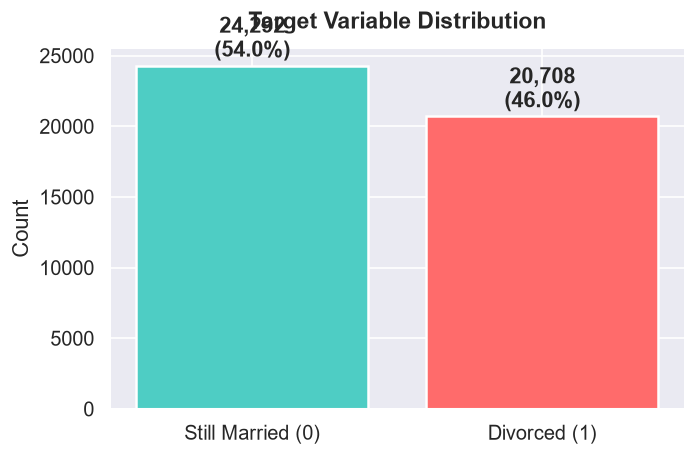

In [16]:
target_counts = df_raw['divorced'].value_counts()
target_pct    = df_raw['divorced'].value_counts(normalize=True) * 100

print('Target Distribution:')
print(pd.DataFrame({'Count': target_counts, 'Pct (%)': target_pct.round(2)}))

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['Still Married (0)', 'Divorced (1)'], target_counts.values,
              color=['#4ECDC4', '#FF6B6B'], edgecolor='white', linewidth=1.5)
for bar, count, pct in zip(bars, target_counts.values, target_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{count:,}\n({pct:.1f}%)', ha='center', va='bottom', fontweight='bold')
ax.set_title('Target Variable Distribution', fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('Count')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()


---
<a id='3'></a>
## 3. 🔍 Exploratory Data Analysis (EDA)


### 3.1 Univariate Analysis — Numerical Features


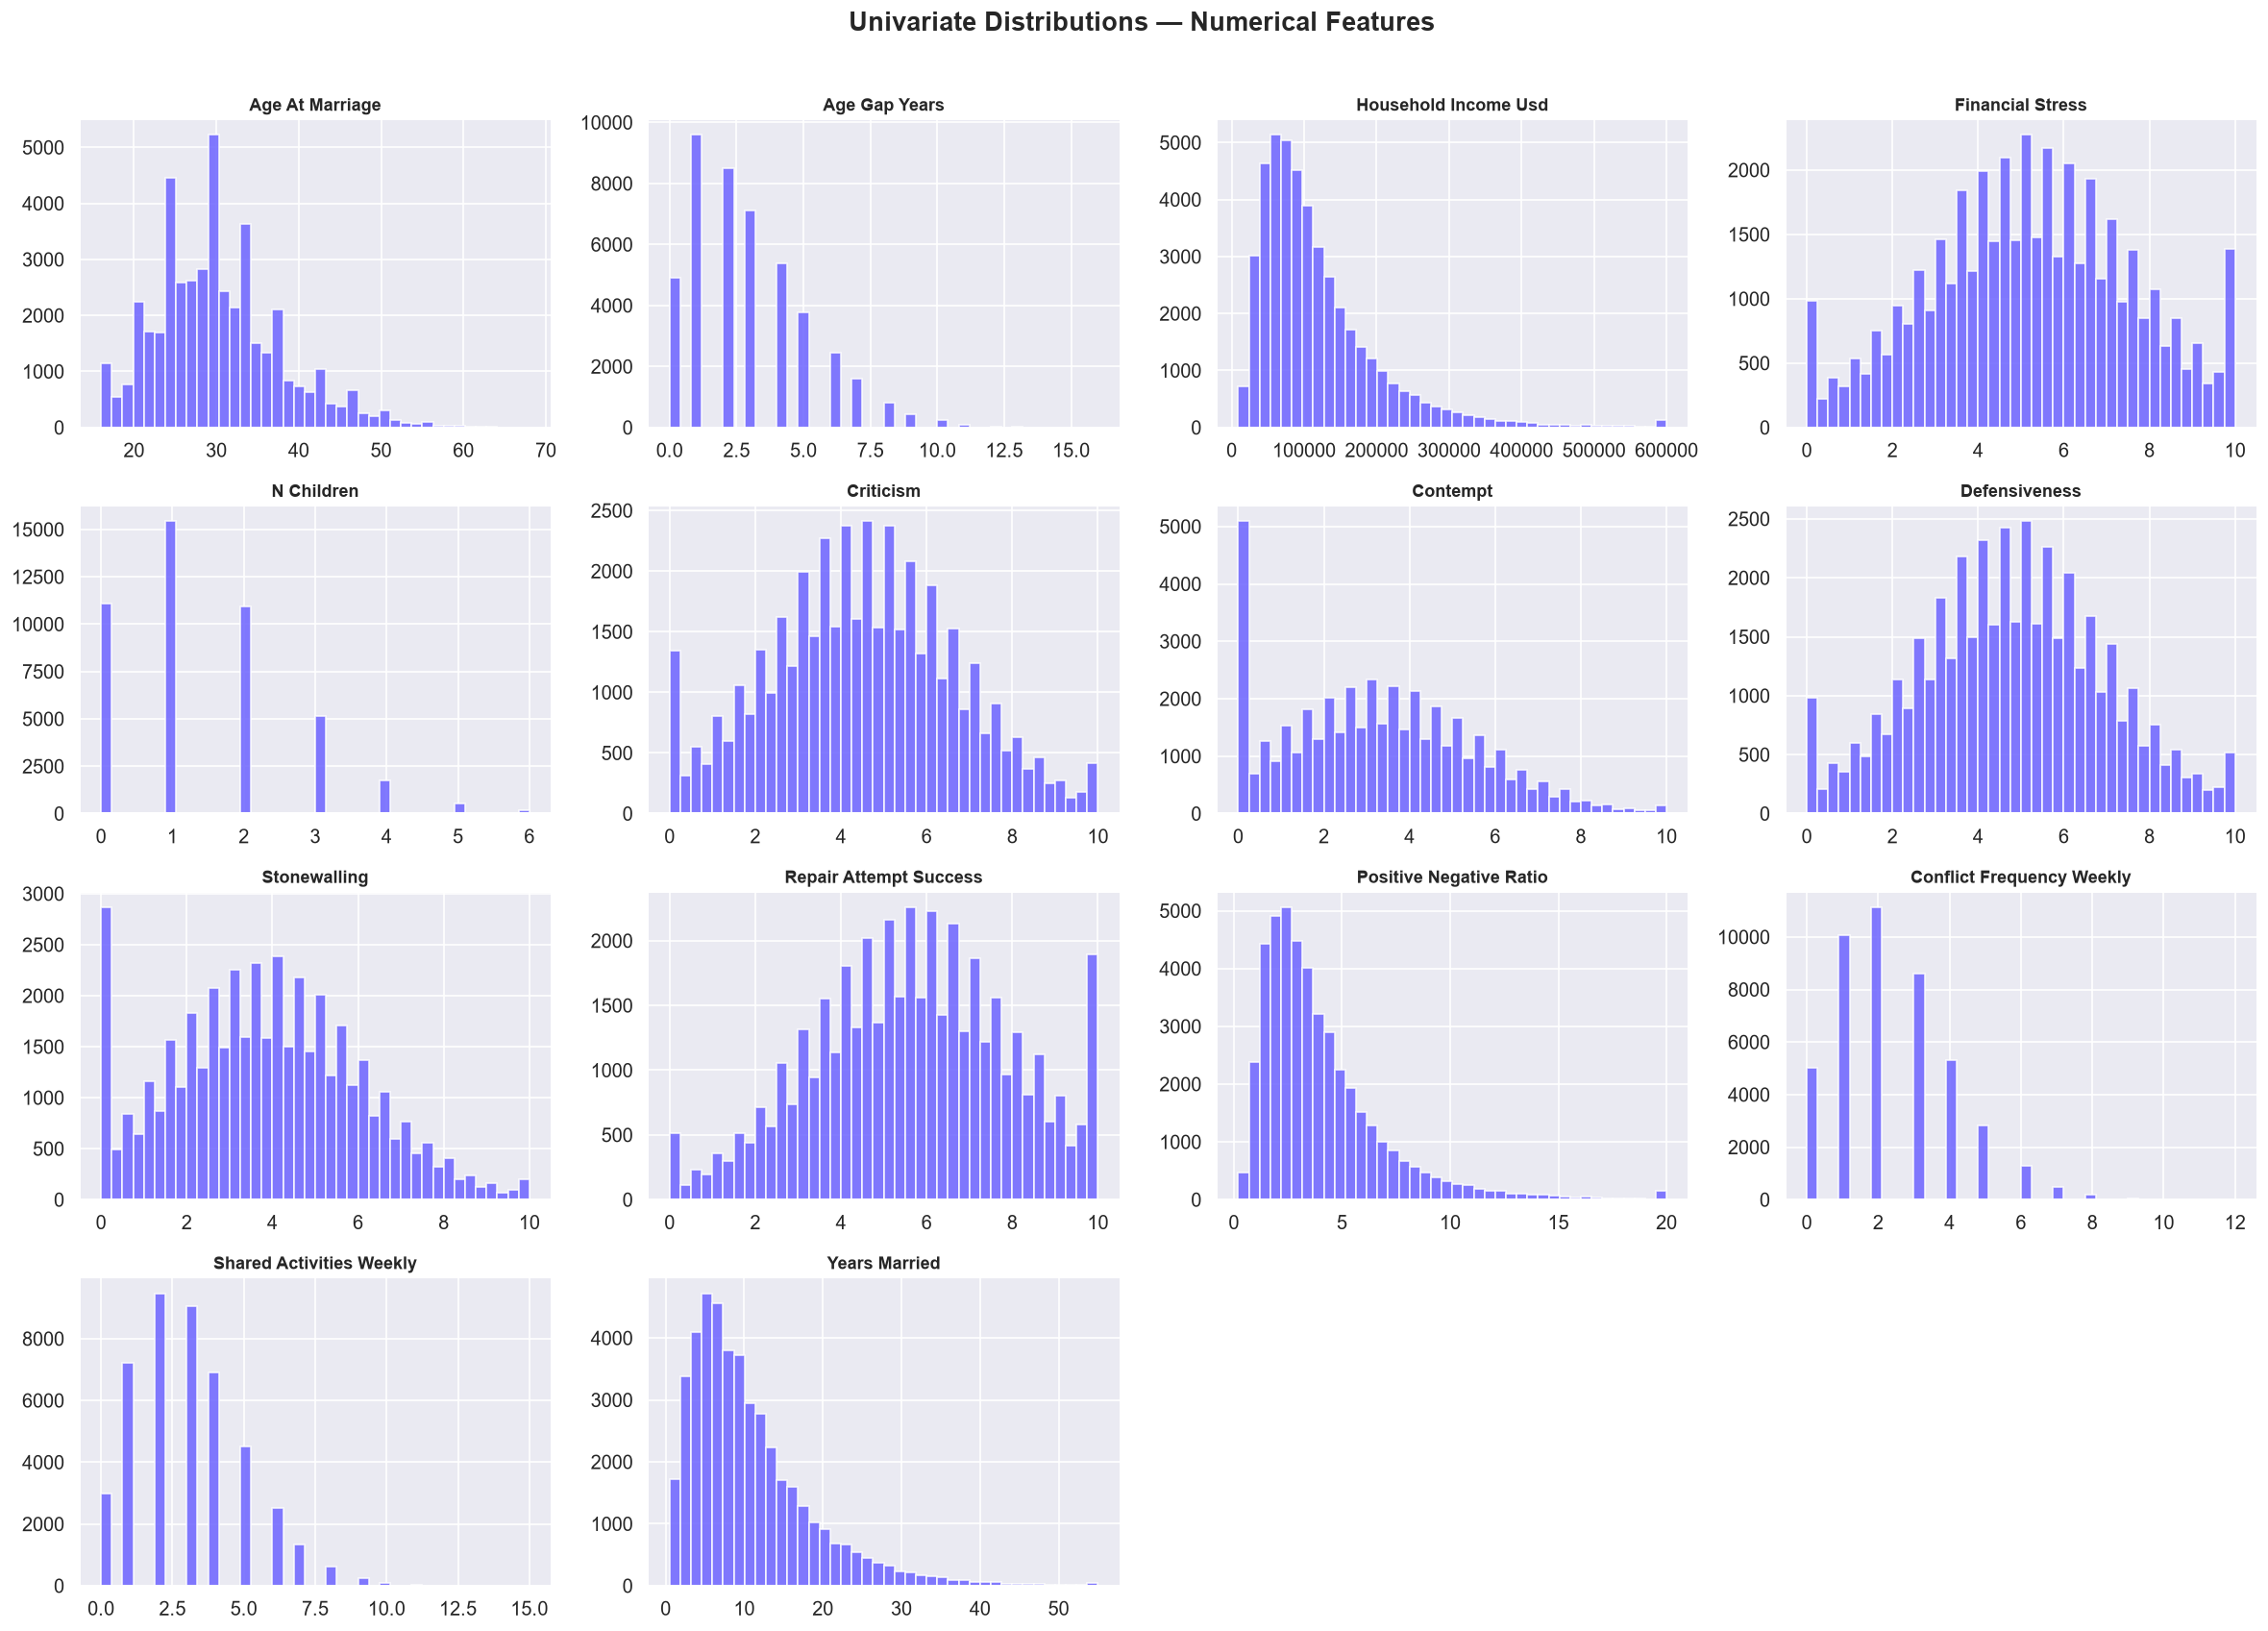

In [17]:
numeric_cols = [
    'age_at_marriage', 'age_gap_years', 'household_income_usd', 'financial_stress',
    'n_children', 'criticism', 'contempt', 'defensiveness', 'stonewalling',
    'repair_attempt_success', 'positive_negative_ratio',
    'conflict_frequency_weekly', 'shared_activities_weekly', 'years_married'
]

n_cols = 4
n_rows = int(np.ceil(len(numeric_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3.5))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df_raw[col].dropna(), bins=40, color='#6C63FF', edgecolor='white', alpha=0.85)
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=11, fontweight='bold')
    axes[i].spines[['top','right']].set_visible(False)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Univariate Distributions — Numerical Features', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


### 3.2 Univariate Analysis — Categorical Features


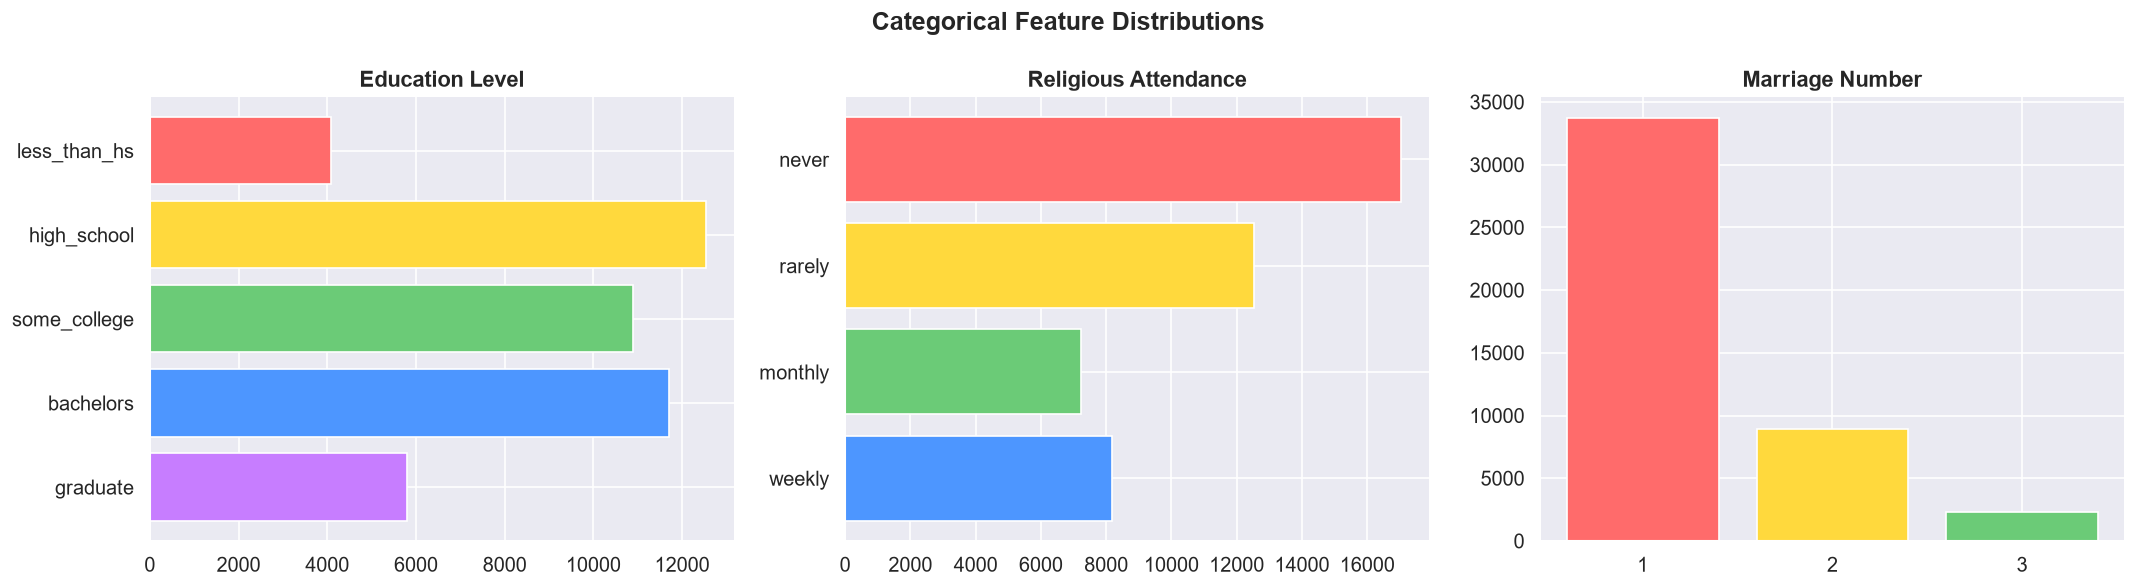

In [18]:
cat_palette = ['#FF6B6B', '#FFD93D', '#6BCB77', '#4D96FF', '#C77DFF']
edu_order   = ['less_than_hs', 'high_school', 'some_college', 'bachelors', 'graduate']
rel_order   = ['never', 'rarely', 'monthly', 'weekly']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

edu_counts = df_raw['education_level'].value_counts().reindex(edu_order)
axes[0].barh(edu_counts.index, edu_counts.values, color=cat_palette[:len(edu_order)])
axes[0].set_title('Education Level', fontweight='bold')
axes[0].invert_yaxis()

rel_counts = df_raw['religious_attendance'].value_counts().reindex(rel_order)
axes[1].barh(rel_counts.index, rel_counts.values, color=cat_palette[:len(rel_order)])
axes[1].set_title('Religious Attendance', fontweight='bold')
axes[1].invert_yaxis()

mar_counts = df_raw['marriage_number'].value_counts().sort_index()
axes[2].bar(mar_counts.index.astype(str), mar_counts.values, color=cat_palette[:len(mar_counts)])
axes[2].set_title('Marriage Number', fontweight='bold')

for ax in axes:
    ax.spines[['top','right']].set_visible(False)

plt.suptitle('Categorical Feature Distributions', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


### 3.3 Bivariate Analysis — Features vs. Target (Divorced)


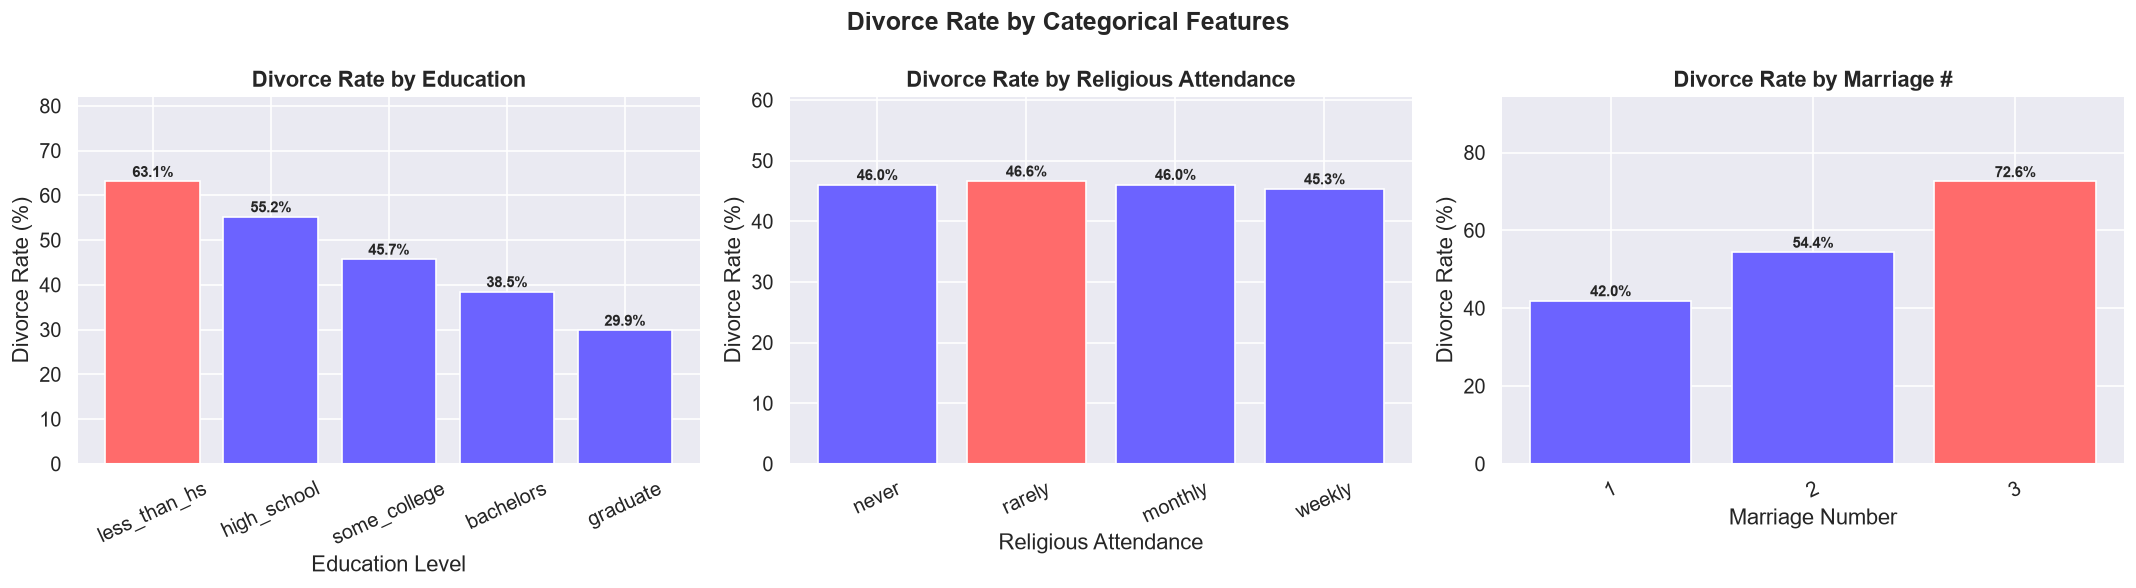

In [19]:
div_by_edu   = (df_raw.groupby('education_level')['divorced'].mean().reindex(edu_order) * 100).round(2)
div_by_rel   = (df_raw.groupby('religious_attendance')['divorced'].mean().reindex(rel_order) * 100).round(2)
div_by_marno = (df_raw.groupby('marriage_number')['divorced'].mean() * 100).round(2)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
data_list  = [div_by_edu, div_by_rel, div_by_marno]
titles     = ['Divorce Rate by Education', 'Divorce Rate by Religious Attendance', 'Divorce Rate by Marriage #']
xlabels    = ['Education Level', 'Religious Attendance', 'Marriage Number']

for ax, data, title, xlabel in zip(axes, data_list, titles, xlabels):
    bars = ax.bar(data.index.astype(str), data.values,
                  color=['#FF6B6B' if v == data.max() else '#6C63FF' for v in data.values])
    for bar, val in zip(bars, data.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Divorce Rate (%)')
    ax.set_ylim(0, data.max() * 1.3)
    ax.tick_params(axis='x', rotation=25)
    ax.spines[['top','right']].set_visible(False)

plt.suptitle('Divorce Rate by Categorical Features', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


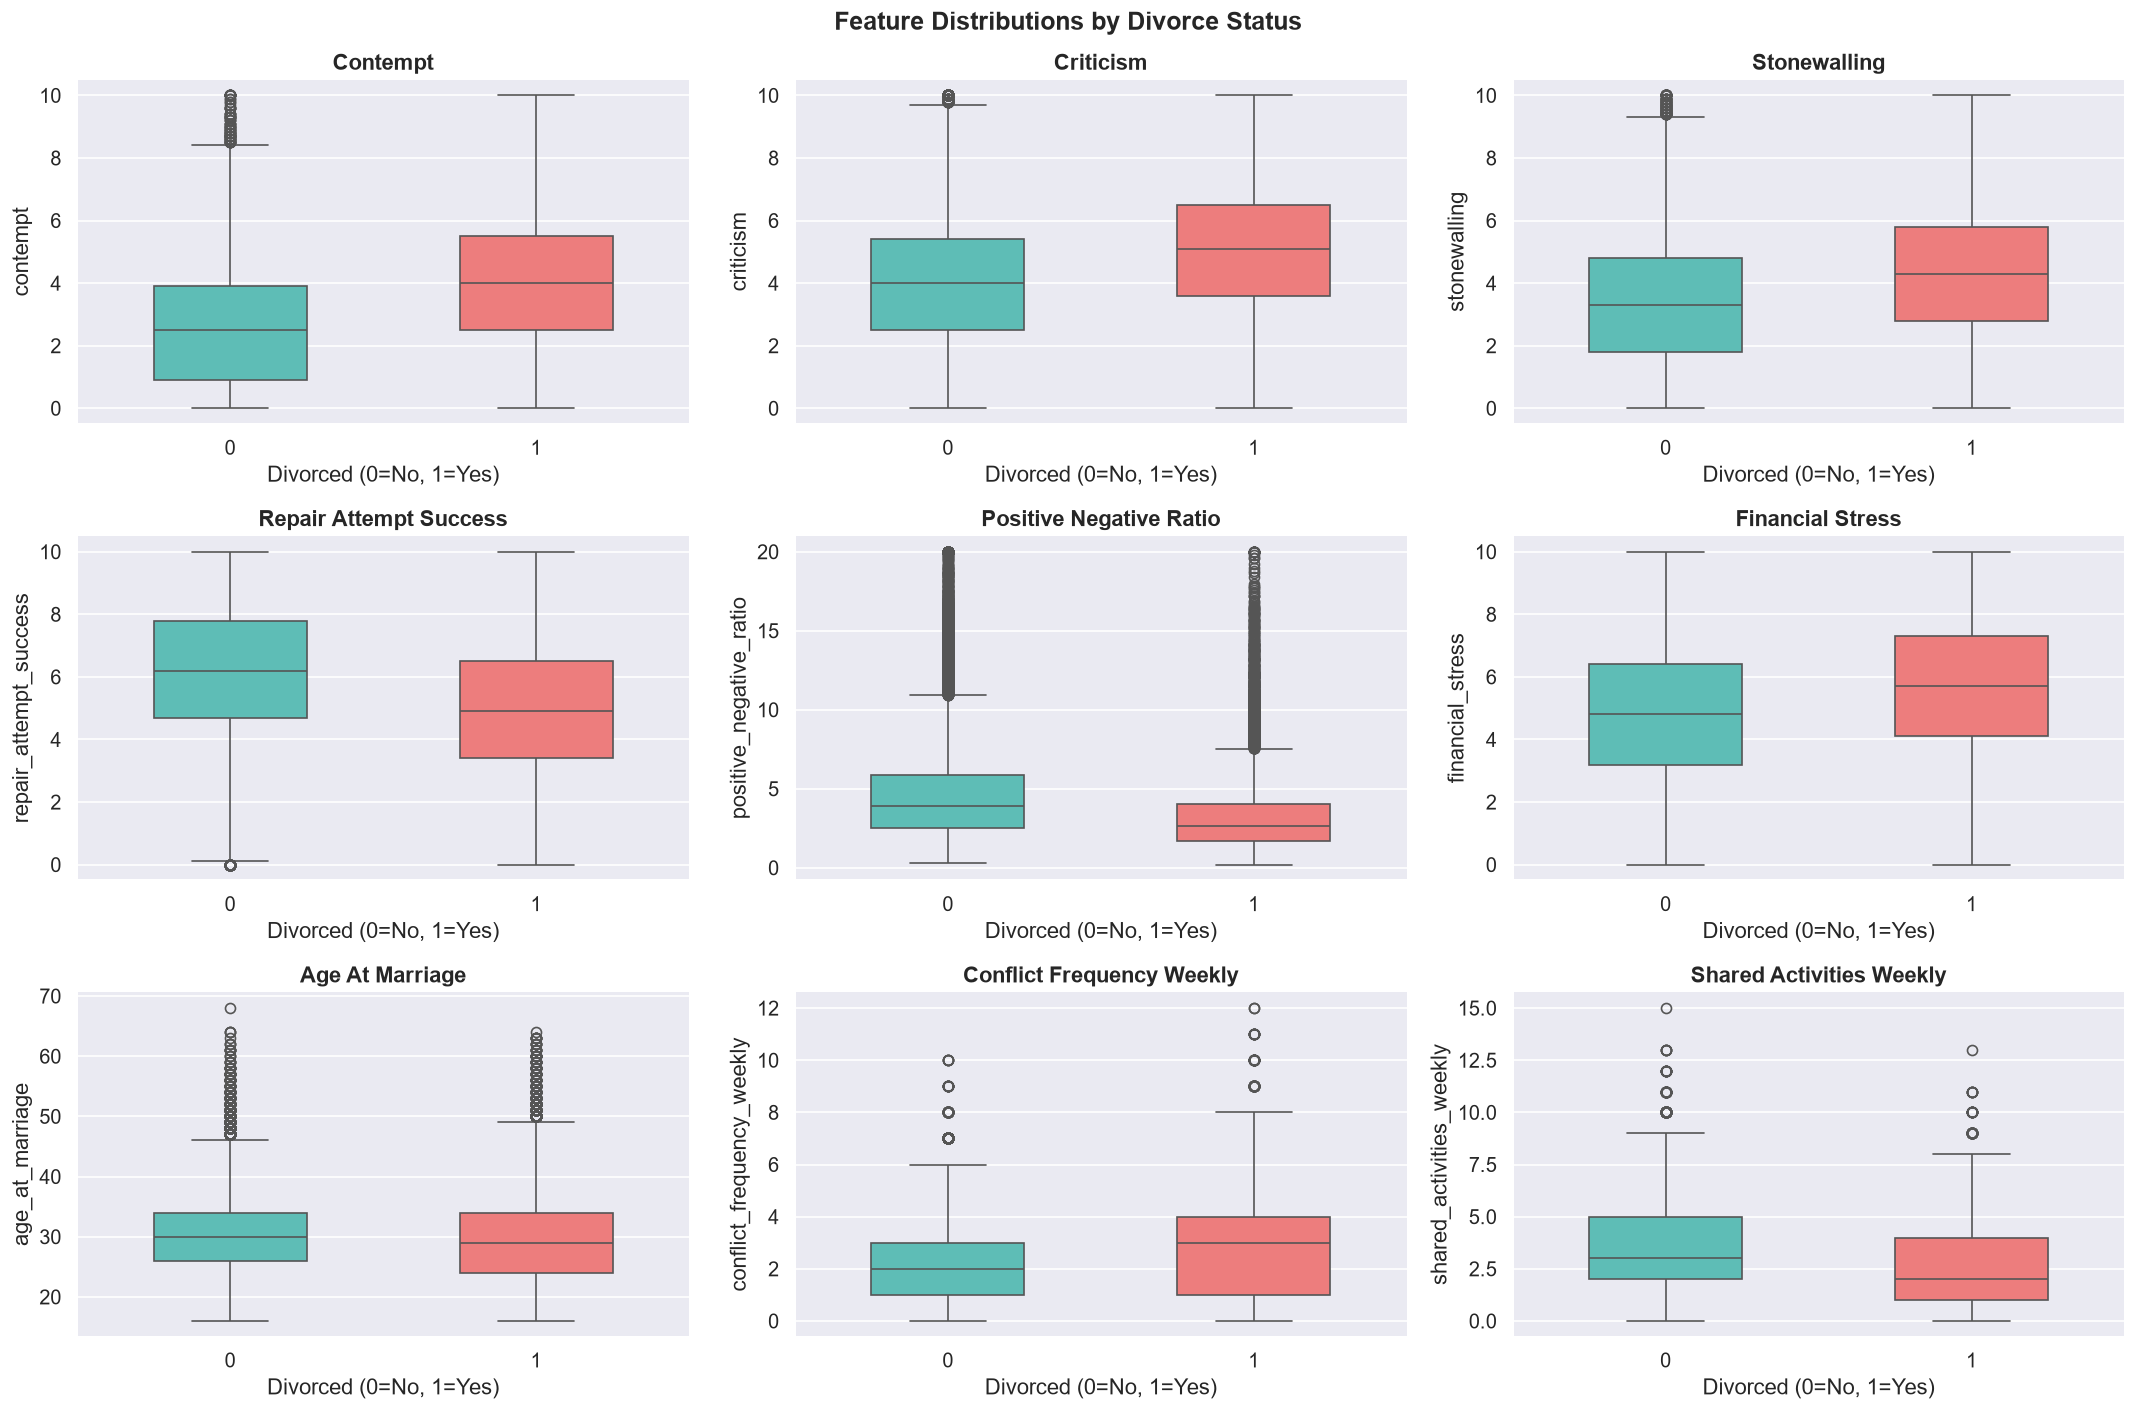

In [20]:
key_numeric = [
    'contempt', 'criticism', 'stonewalling', 'repair_attempt_success',
    'positive_negative_ratio', 'financial_stress', 'age_at_marriage',
    'conflict_frequency_weekly', 'shared_activities_weekly'
]

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()
box_palette = ['#4ECDC4', '#FF6B6B']

for i, col in enumerate(key_numeric):
    sns.boxplot(data=df_raw, x='divorced', y=col, hue='divorced',
                palette=box_palette, ax=axes[i], width=0.5, legend=False)
    axes[i].set_title(col.replace('_', ' ').title(), fontweight='bold')
    axes[i].set_xlabel('Divorced (0=No, 1=Yes)')
    axes[i].spines[['top','right']].set_visible(False)

plt.suptitle('Feature Distributions by Divorce Status', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


### 3.4 Correlation Heatmap


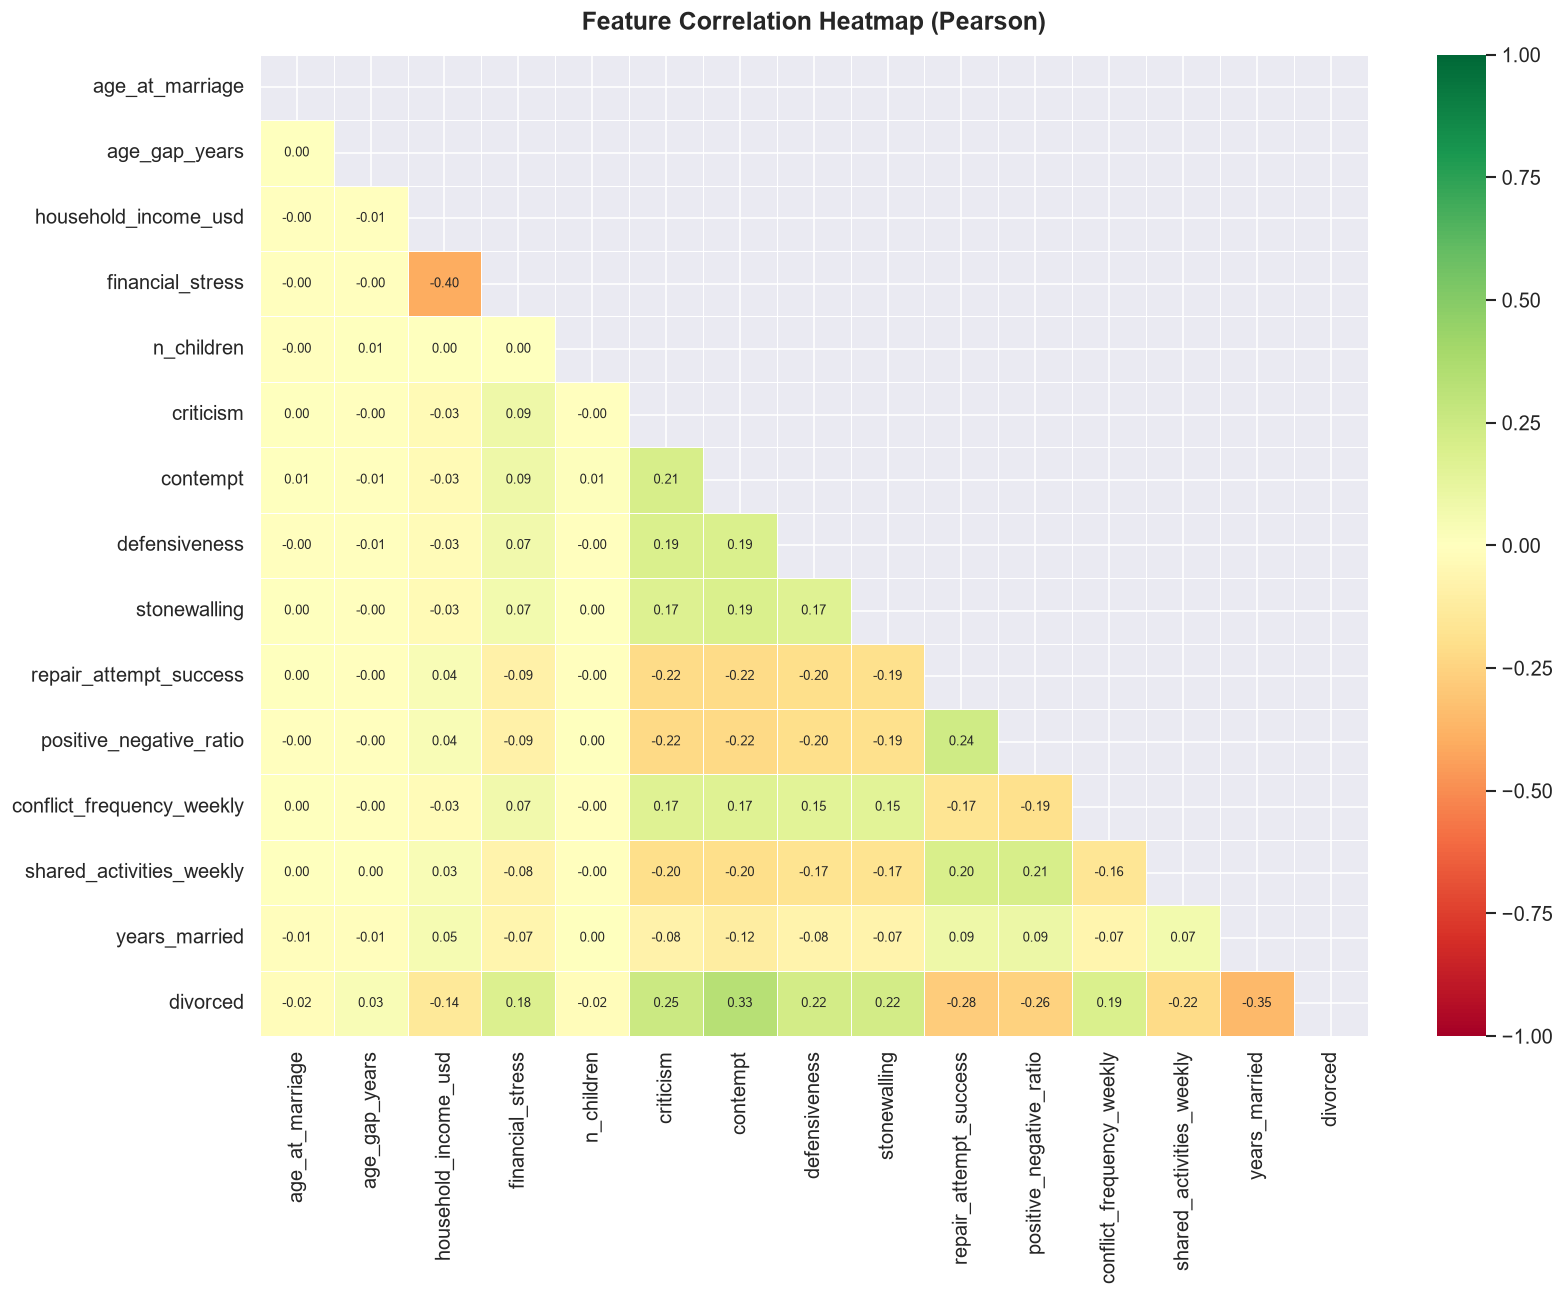

In [21]:
corr_cols   = numeric_cols + ['divorced']
corr_matrix = df_raw[corr_cols].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Feature Correlation Heatmap (Pearson)', fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


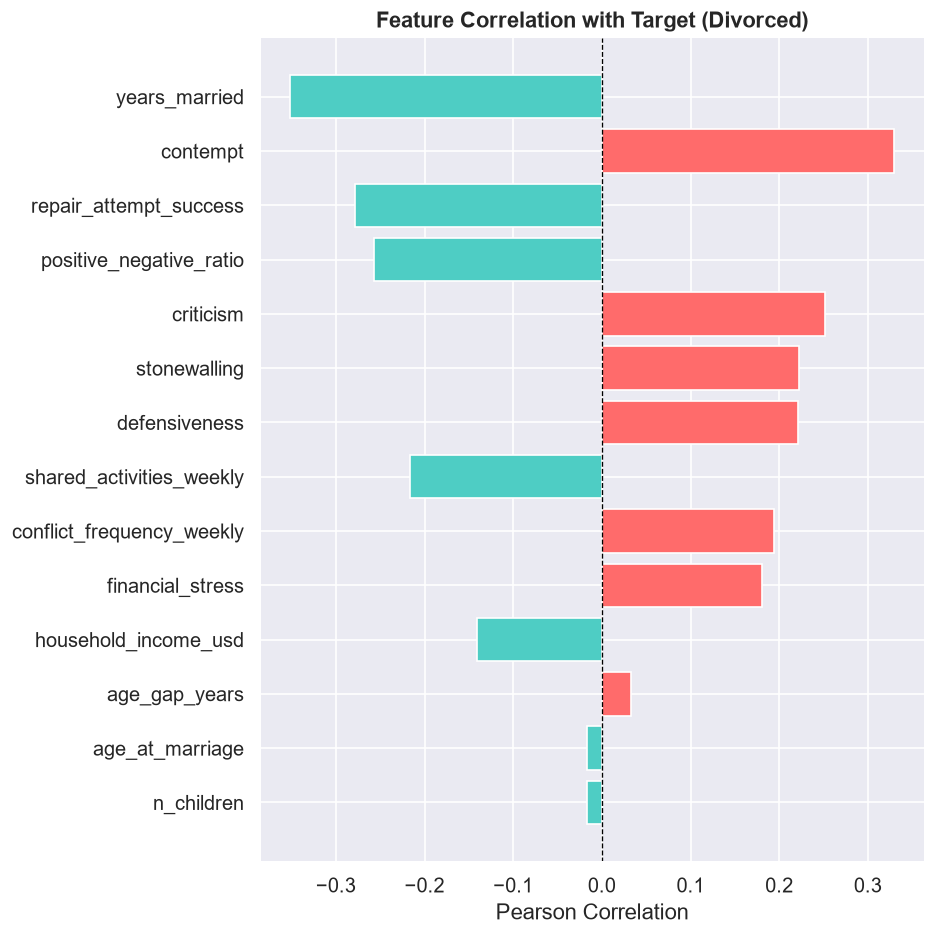

In [22]:
corr_with_target = corr_matrix['divorced'].drop('divorced').sort_values(key=abs, ascending=True)

fig, ax = plt.subplots(figsize=(8, 8))
colors_bar = ['#FF6B6B' if v > 0 else '#4ECDC4' for v in corr_with_target.values]
ax.barh(corr_with_target.index, corr_with_target.values, color=colors_bar)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Feature Correlation with Target (Divorced)', fontweight='bold', fontsize=13)
ax.set_xlabel('Pearson Correlation')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()


### 3.5 Gottman's Four Horsemen Deep-Dive

Gottman identified **Criticism, Contempt, Defensiveness, and Stonewalling** as the four
strongest behavioral predictors of divorce. We validate this empirically below.


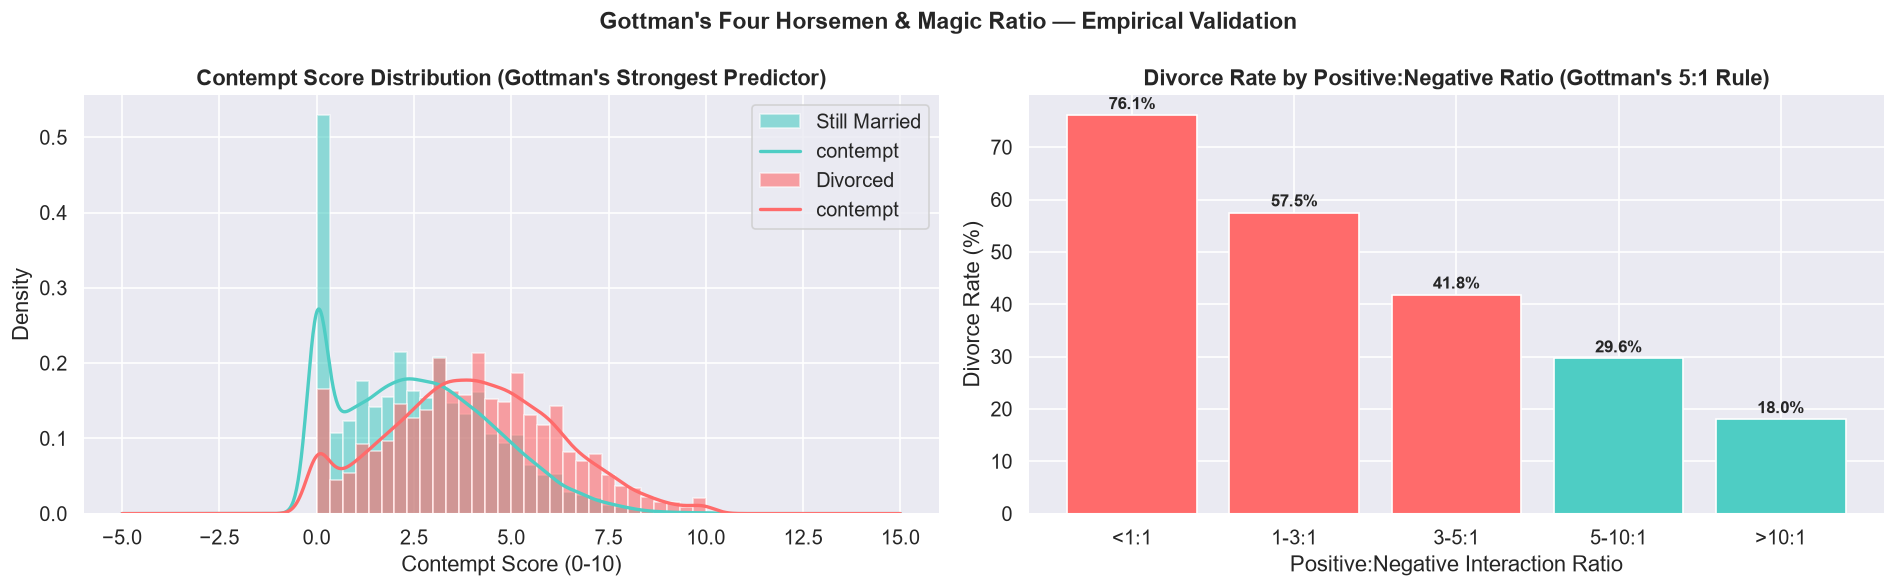

In [23]:
horsemen = ['criticism', 'contempt', 'defensiveness', 'stonewalling']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Contempt KDE
for status, color, label in zip([0, 1], ['#4ECDC4', '#FF6B6B'], ['Still Married', 'Divorced']):
    subset = df_raw[df_raw['divorced'] == status]['contempt']
    axes[0].hist(subset, bins=30, alpha=0.6, color=color, label=label, density=True, edgecolor='white')
    subset.plot.kde(ax=axes[0], color=color, linewidth=2)
axes[0].set_title("Contempt Score Distribution (Gottman's Strongest Predictor)", fontweight='bold')
axes[0].set_xlabel('Contempt Score (0-10)')
axes[0].legend()
axes[0].spines[['top','right']].set_visible(False)

# PNR buckets
df_raw['pnr_bucket'] = pd.cut(
    df_raw['positive_negative_ratio'],
    bins=[0, 1, 3, 5, 10, 100],
    labels=['<1:1', '1-3:1', '3-5:1', '5-10:1', '>10:1']
)
div_by_pnr = df_raw.groupby('pnr_bucket', observed=True)['divorced'].mean() * 100
bars = axes[1].bar(div_by_pnr.index.astype(str), div_by_pnr.values,
                    color=['#FF6B6B' if v > 40 else '#4ECDC4' for v in div_by_pnr.values])
for bar, val in zip(bars, div_by_pnr.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=10)
axes[1].set_title("Divorce Rate by Positive:Negative Ratio (Gottman's 5:1 Rule)", fontweight='bold')
axes[1].set_xlabel('Positive:Negative Interaction Ratio')
axes[1].set_ylabel('Divorce Rate (%)')
axes[1].spines[['top','right']].set_visible(False)

plt.suptitle("Gottman's Four Horsemen & Magic Ratio — Empirical Validation",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


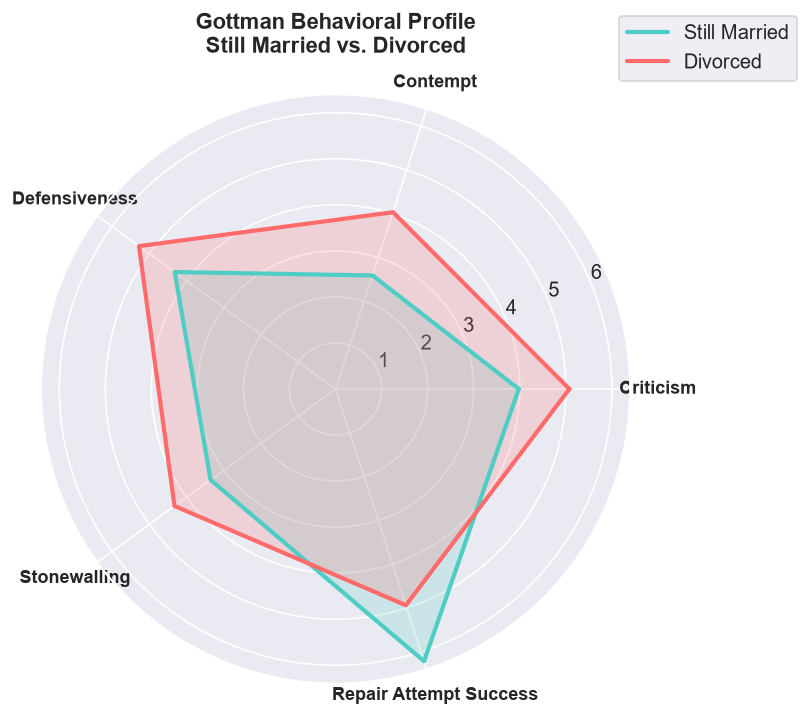

Mean Gottman Scores by Divorce Status:


divorced,Still Married,Divorced
criticism,3.977915,5.076859
contempt,2.592166,4.035580
defensiveness,4.319047,5.277849
stonewalling,3.356521,4.323648
repair_attempt_success,6.216355,4.939115


In [24]:
# Radar Chart: Behavioral Profile
horsemen_means = df_raw.groupby('divorced')[horsemen + ['repair_attempt_success']].mean()

categories = [h.replace('_', ' ').title() for h in horsemen + ['repair_attempt_success']]
N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
for status, color, label in zip([0, 1], ['#4ECDC4', '#FF6B6B'], ['Still Married', 'Divorced']):
    values = horsemen_means.loc[status].tolist() + horsemen_means.loc[status].tolist()[:1]
    ax.plot(angles, values, color=color, linewidth=2.5, label=label)
    ax.fill(angles, values, color=color, alpha=0.2)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11, fontweight='bold')
ax.set_title('Gottman Behavioral Profile\nStill Married vs. Divorced',
             fontsize=13, fontweight='bold', pad=25)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.15))
plt.tight_layout()
plt.show()

print('Mean Gottman Scores by Divorce Status:')
display(horsemen_means.T.rename(columns={0: 'Still Married', 1: 'Divorced'}))


---
<a id='4'></a>
## 4. 🛠️ Data Preprocessing & Feature Engineering

Encode categorical variables, engineer new domain-informed features,
handle missing data, and create a stratified train/test split.


In [25]:
df = df_raw.copy()

# Drop ID and data-leakage columns
df.drop(columns=['marriage_id', 'years_to_divorce', 'pnr_bucket'], errors='ignore', inplace=True)

# 1. Four Horsemen composite score (higher = worse)
df['horsemen_total'] = df[['criticism', 'contempt', 'defensiveness', 'stonewalling']].sum(axis=1)

# 2. Conflict-to-Activity Ratio (higher = worse balance)
df['conflict_to_activity_ratio'] = df['conflict_frequency_weekly'] / (df['shared_activities_weekly'] + 0.01)

# 3. Gottman PNR risk flag (below 5:1 is risky)
df['pnr_risk'] = (df['positive_negative_ratio'] < 5).astype(int)

# 4. High contempt flag (above median)
df['high_contempt'] = (df['contempt'] > df['contempt'].median()).astype(int)

# 5. Financial burden (stress amplified when only one earner)
df['financial_burden'] = df['financial_stress'] * (1 - df['both_employed'])

# 6. Young marriage risk flag
df['young_marriage'] = (df['age_at_marriage'] < 25).astype(int)

print('Feature engineering complete.')
print('New features: horsemen_total, conflict_to_activity_ratio, pnr_risk, high_contempt, financial_burden, young_marriage')


Feature engineering complete.
New features: horsemen_total, conflict_to_activity_ratio, pnr_risk, high_contempt, financial_burden, young_marriage


In [26]:
# Ordinal encoding for ordered categorical variables
edu_order_map = {'less_than_hs': 0, 'high_school': 1, 'some_college': 2, 'bachelors': 3, 'graduate': 4}
rel_order_map = {'never': 0, 'rarely': 1, 'monthly': 2, 'weekly': 3}

df['education_level']      = df['education_level'].map(edu_order_map)
df['religious_attendance'] = df['religious_attendance'].map(rel_order_map)

print(f'Encoding complete. Final shape: {df.shape}')
df.head(3)


Encoding complete. Final shape: (45000, 28)


,marriage_number,age_at_marriage,age_gap_years,education_level,household_income_usd,financial_stress,both_employed,cohabited_before,premarital_counseling,child_before_marriage,...,conflict_frequency_weekly,shared_activities_weekly,years_married,divorced,horsemen_total,conflict_to_activity_ratio,pnr_risk,high_contempt,financial_burden,young_marriage
0,1,36,6,0,68600.0,5.9,1,1,0,0,...,3.0,4.0,22.0,0,26.4,0.748130,1,1,0.0,0
1,2,59,1,2,328800.0,0.0,1,1,0,0,...,1.0,1.0,15.5,0,11.7,0.990099,0,0,0.0,0
2,2,44,1,1,139900.0,6.1,0,0,1,0,...,4.0,2.0,7.2,0,20.7,1.990050,1,1,6.1,0


In [27]:
FEATURE_COLS = [c for c in df.columns if c != 'divorced']
TARGET_COL   = 'divorced'

X = df[FEATURE_COLS]
y = df[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pw  = neg / pos

print(f'Training : {X_train.shape[0]:,} samples  ({y_train.mean()*100:.1f}% divorced)')
print(f'Test     : {X_test.shape[0]:,} samples  ({y_test.mean()*100:.1f}% divorced)')
print(f'scale_pos_weight = {scale_pw:.3f}')


Training : 36,000 samples  (46.0% divorced)
Test     : 9,000 samples  (46.0% divorced)
scale_pos_weight = 1.173


---
<a id='5'></a>
## 5. 🔀 Baseline Models

Establish performance benchmarks with Logistic Regression, Decision Tree,
and Random Forest before training advanced models.


In [28]:
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1] if hasattr(model, 'predict_proba') else None
    return {
        'Model'    : name,
        'Accuracy' : accuracy_score(y_te, y_pred),
        'ROC-AUC'  : roc_auc_score(y_te, y_prob) if y_prob is not None else float('nan'),
        'F1-Score' : f1_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred),
        'Recall'   : recall_score(y_te, y_pred),
    }, model

results_log = []

res, _ = evaluate_model('Logistic Regression',
    LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE),
    X_train_sc, y_train, X_test_sc, y_test)
results_log.append(res)
print(f"  Logistic Regression  ROC-AUC: {res['ROC-AUC']:.4f}  F1: {res['F1-Score']:.4f}")

res, _ = evaluate_model('Decision Tree',
    DecisionTreeClassifier(max_depth=8, class_weight='balanced', random_state=RANDOM_STATE),
    X_train, y_train, X_test, y_test)
results_log.append(res)
print(f"  Decision Tree        ROC-AUC: {res['ROC-AUC']:.4f}  F1: {res['F1-Score']:.4f}")

res, _ = evaluate_model('Random Forest',
    RandomForestClassifier(n_estimators=200, class_weight='balanced',
                           n_jobs=-1, random_state=RANDOM_STATE),
    X_train, y_train, X_test, y_test)
results_log.append(res)
print(f"  Random Forest        ROC-AUC: {res['ROC-AUC']:.4f}  F1: {res['F1-Score']:.4f}")

df_baseline = pd.DataFrame(results_log).set_index('Model')
display(df_baseline.style.format('{:.4f}').background_gradient(cmap='Greens', axis=None))


  Logistic Regression  ROC-AUC: 0.8725  F1: 0.7792
  Decision Tree        ROC-AUC: 0.8239  F1: 0.7323
  Random Forest        ROC-AUC: 0.8595  F1: 0.7659


,Accuracy,ROC-AUC,F1-Score,Precision,Recall
Model,,,,,
Logistic Regression,0.7904,0.8725,0.7792,0.7565,0.8032
Decision Tree,0.7414,0.8239,0.7323,0.6995,0.7682
Random Forest,0.7818,0.8595,0.7659,0.7565,0.7755


---
<a id='6'></a>
## 6. ⚡ Advanced Models — XGBoost, LightGBM & CatBoost

Train three state-of-the-art gradient boosting frameworks with early stopping
and class-imbalance correction via `scale_pos_weight`.


In [29]:
# XGBoost
xgb_model = xgb.XGBClassifier(
    n_estimators=500, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=scale_pw,
    eval_metric='auc', early_stopping_rounds=30,
    use_label_encoder=False, random_state=RANDOM_STATE, n_jobs=-1
)
xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

xgb_pred  = xgb_model.predict(X_test)
xgb_prob  = xgb_model.predict_proba(X_test)[:, 1]
res_xgb   = {
    'Model'    : 'XGBoost',
    'Accuracy' : accuracy_score(y_test, xgb_pred),
    'ROC-AUC'  : roc_auc_score(y_test, xgb_prob),
    'F1-Score' : f1_score(y_test, xgb_pred),
    'Precision': precision_score(y_test, xgb_pred),
    'Recall'   : recall_score(y_test, xgb_pred),
}
results_log.append(res_xgb)
print(f"  XGBoost   ROC-AUC: {res_xgb['ROC-AUC']:.4f}  F1: {res_xgb['F1-Score']:.4f}")


  XGBoost   ROC-AUC: 0.8726  F1: 0.7773


In [30]:
# LightGBM
lgb_model = lgb.LGBMClassifier(
    n_estimators=500, learning_rate=0.05, num_leaves=63,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=scale_pw,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
)
lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(period=-1)]
)

lgb_pred = lgb_model.predict(X_test)
lgb_prob = lgb_model.predict_proba(X_test)[:, 1]
res_lgb  = {
    'Model'    : 'LightGBM',
    'Accuracy' : accuracy_score(y_test, lgb_pred),
    'ROC-AUC'  : roc_auc_score(y_test, lgb_prob),
    'F1-Score' : f1_score(y_test, lgb_pred),
    'Precision': precision_score(y_test, lgb_pred),
    'Recall'   : recall_score(y_test, lgb_pred),
}
results_log.append(res_lgb)
print(f"  LightGBM  ROC-AUC: {res_lgb['ROC-AUC']:.4f}  F1: {res_lgb['F1-Score']:.4f}")


  LightGBM  ROC-AUC: 0.8718  F1: 0.7787


In [31]:
# CatBoost
cb_model = cb.CatBoostClassifier(
    iterations=500, learning_rate=0.05, depth=6,
    class_weights=[1, scale_pw],
    eval_metric='AUC', early_stopping_rounds=30,
    random_seed=RANDOM_STATE, verbose=0
)
cb_model.fit(X_train, y_train, eval_set=(X_test, y_test))

cb_pred = cb_model.predict(X_test)
cb_prob = cb_model.predict_proba(X_test)[:, 1]
res_cb  = {
    'Model'    : 'CatBoost',
    'Accuracy' : accuracy_score(y_test, cb_pred),
    'ROC-AUC'  : roc_auc_score(y_test, cb_prob),
    'F1-Score' : f1_score(y_test, cb_pred),
    'Precision': precision_score(y_test, cb_pred),
    'Recall'   : recall_score(y_test, cb_pred),
}
results_log.append(res_cb)
print(f"  CatBoost  ROC-AUC: {res_cb['ROC-AUC']:.4f}  F1: {res_cb['F1-Score']:.4f}")


  CatBoost  ROC-AUC: 0.8747  F1: 0.7811


---
<a id='7'></a>
## 7. 🔧 Hyperparameter Tuning with Optuna

Use Optuna's TPE sampler to efficiently search the LightGBM hyperparameter space,
optimizing ROC-AUC via 5-fold Stratified Cross-Validation (50 trials).


In [32]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def objective_lgb(trial):
    params = {
        'n_estimators'      : trial.suggest_int('n_estimators', 200, 1000),
        'learning_rate'     : trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'num_leaves'        : trial.suggest_int('num_leaves', 20, 200),
        'max_depth'         : trial.suggest_int('max_depth', 3, 12),
        'subsample'         : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree'  : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha'         : trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda'        : trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'min_child_samples' : trial.suggest_int('min_child_samples', 5, 100),
        'scale_pos_weight'  : scale_pw,
        'random_state'      : RANDOM_STATE,
        'n_jobs'            : -1,
        'verbose'           : -1,
    }
    model  = lgb.LGBMClassifier(**params)
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    return scores.mean()

study = optuna.create_study(direction='maximize', study_name='lgb_divorce')
study.optimize(objective_lgb, n_trials=50, show_progress_bar=True)

print(f'Best ROC-AUC (5-fold CV): {study.best_value:.4f}')
print(f'Best params : {study.best_params}')


Best trial: 34. Best value: 0.866292: 100%|██████████| 50/50 [05:17<00:00,  6.34s/it]

Best ROC-AUC (5-fold CV): 0.8663
Best params : {'n_estimators': 447, 'learning_rate': 0.044621486360875366, 'num_leaves': 21, 'max_depth': 3, 'subsample': 0.8740209708467005, 'colsample_bytree': 0.8423618629729406, 'reg_alpha': 2.6830599078413033e-07, 'reg_lambda': 0.00014338023384602967, 'min_child_samples': 21}


In [33]:
best_params = {**study.best_params,
               'scale_pos_weight': scale_pw,
               'random_state': RANDOM_STATE,
               'n_jobs': -1, 'verbose': -1}

lgb_tuned = lgb.LGBMClassifier(**best_params)
lgb_tuned.fit(X_train, y_train)

tuned_pred = lgb_tuned.predict(X_test)
tuned_prob = lgb_tuned.predict_proba(X_test)[:, 1]

res_tuned = {
    'Model'    : 'LightGBM (Tuned)',
    'Accuracy' : accuracy_score(y_test, tuned_pred),
    'ROC-AUC'  : roc_auc_score(y_test, tuned_prob),
    'F1-Score' : f1_score(y_test, tuned_pred),
    'Precision': precision_score(y_test, tuned_pred),
    'Recall'   : recall_score(y_test, tuned_pred),
}
results_log.append(res_tuned)
print(f"  LightGBM (Tuned)  ROC-AUC: {res_tuned['ROC-AUC']:.4f}  F1: {res_tuned['F1-Score']:.4f}")


  LightGBM (Tuned)  ROC-AUC: 0.8738  F1: 0.7806


---
<a id='8'></a>
## 8. 📊 Model Evaluation & Comparison

Consolidate all model results, compare visually, and generate ROC curves
and a confusion matrix for the best model.


In [34]:
df_all = pd.DataFrame(results_log).set_index('Model').sort_values('ROC-AUC', ascending=False)
print('Full Model Comparison:')
display(df_all.style.format('{:.4f}').background_gradient(cmap='YlGn', axis=None))


Full Model Comparison:


,Accuracy,ROC-AUC,F1-Score,Precision,Recall
Model,,,,,
CatBoost,0.7922,0.8747,0.7811,0.7581,0.8056
LightGBM (Tuned),0.7912,0.8738,0.7806,0.7558,0.8071
XGBoost,0.7888,0.8726,0.7773,0.7551,0.8008
Logistic Regression,0.7904,0.8725,0.7792,0.7565,0.8032
LightGBM,0.7904,0.8718,0.7787,0.7575,0.8011
Random Forest,0.7818,0.8595,0.7659,0.7565,0.7755
Decision Tree,0.7414,0.8239,0.7323,0.6995,0.7682


In [35]:
metrics = ['ROC-AUC', 'F1-Score', 'Accuracy', 'Precision', 'Recall']
df_melt = df_all[metrics].reset_index().melt(id_vars='Model', var_name='Metric', value_name='Score')

fig = px.bar(df_melt, x='Model', y='Score', color='Metric', barmode='group',
             title='Model Performance Comparison',
             color_discrete_sequence=px.colors.qualitative.Bold,
             template='plotly_dark')
fig.update_layout(yaxis_range=[0, 1.05])
fig.show()


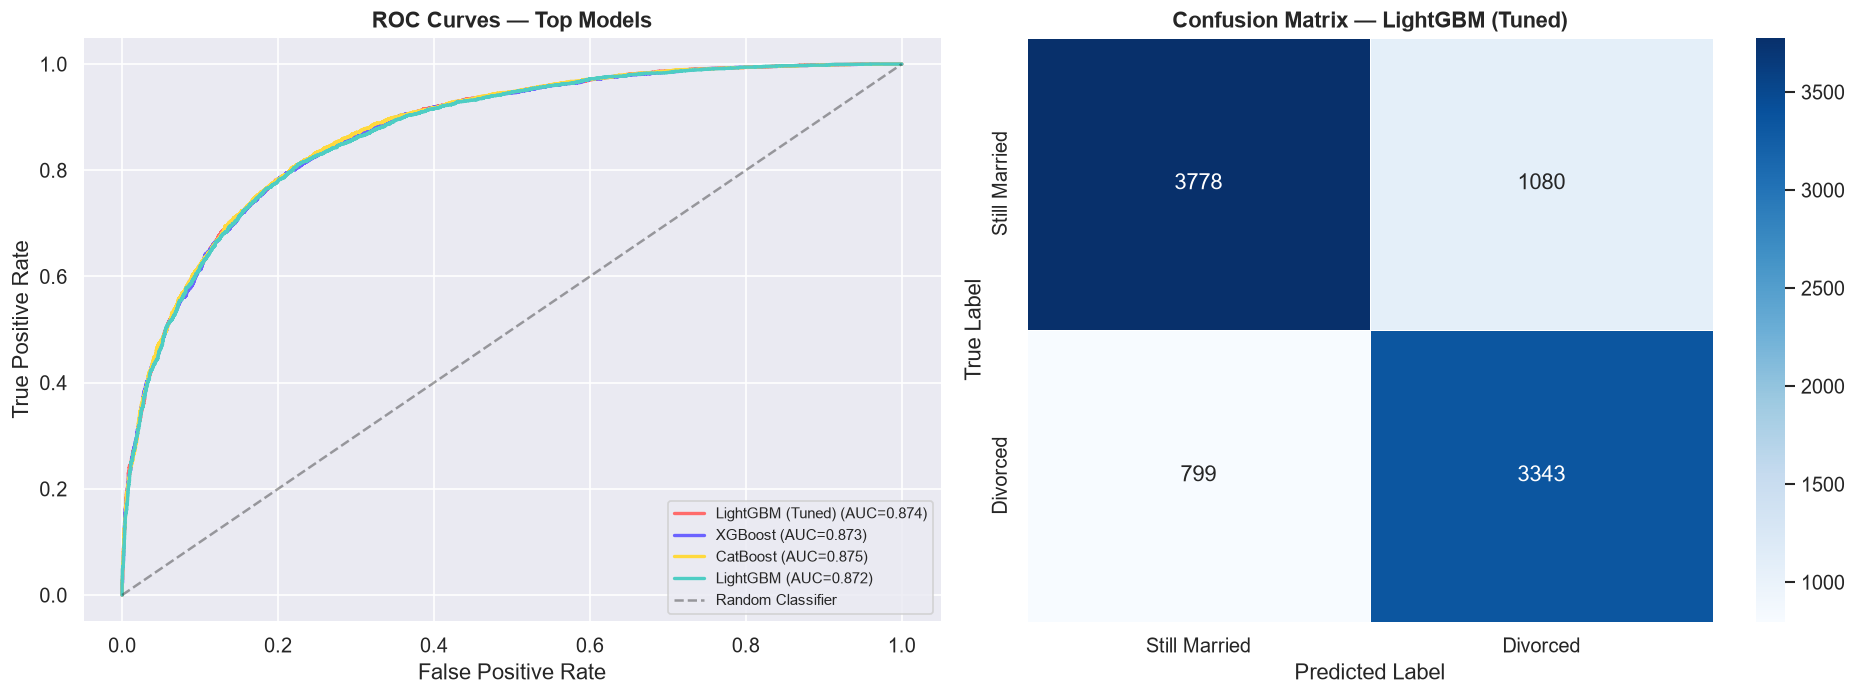

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_models = [
    ('LightGBM (Tuned)', lgb_tuned, X_test, '#FF6B6B'),
    ('XGBoost',          xgb_model, X_test, '#6C63FF'),
    ('CatBoost',         cb_model,  X_test, '#FFD93D'),
    ('LightGBM',         lgb_model, X_test, '#4ECDC4'),
]

from sklearn.metrics import roc_curve

# ROC Curves — manual plot agar compatible semua versi sklearn
for name, model, X_t, color in top_models:
    prob = model.predict_proba(X_t)[:, 1]
    auc  = roc_auc_score(y_test, prob)
    fpr, tpr, _ = roc_curve(y_test, prob)
    axes[0].plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC={auc:.3f})')

axes[0].plot([0,1],[0,1],'k--', alpha=0.4, label='Random Classifier')
axes[0].set_title('ROC Curves — Top Models', fontweight='bold', fontsize=13)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(fontsize=9)
axes[0].spines[['top','right']].set_visible(False)

# Confusion Matrix — Best Model
cm = confusion_matrix(y_test, lgb_tuned.predict(X_test))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Still Married', 'Divorced'],
            yticklabels=['Still Married', 'Divorced'], linewidths=0.5)
axes[1].set_title('Confusion Matrix — LightGBM (Tuned)', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()


In [40]:
print('Detailed Classification Report — LightGBM (Tuned):')
print(classification_report(
    y_test, lgb_tuned.predict(X_test),
    target_names=['Still Married (0)', 'Divorced (1)']
))


Detailed Classification Report — LightGBM (Tuned):
                   precision    recall  f1-score   support

Still Married (0)       0.83      0.78      0.80      4858
     Divorced (1)       0.76      0.81      0.78      4142

         accuracy                           0.79      9000
        macro avg       0.79      0.79      0.79      9000
     weighted avg       0.79      0.79      0.79      9000



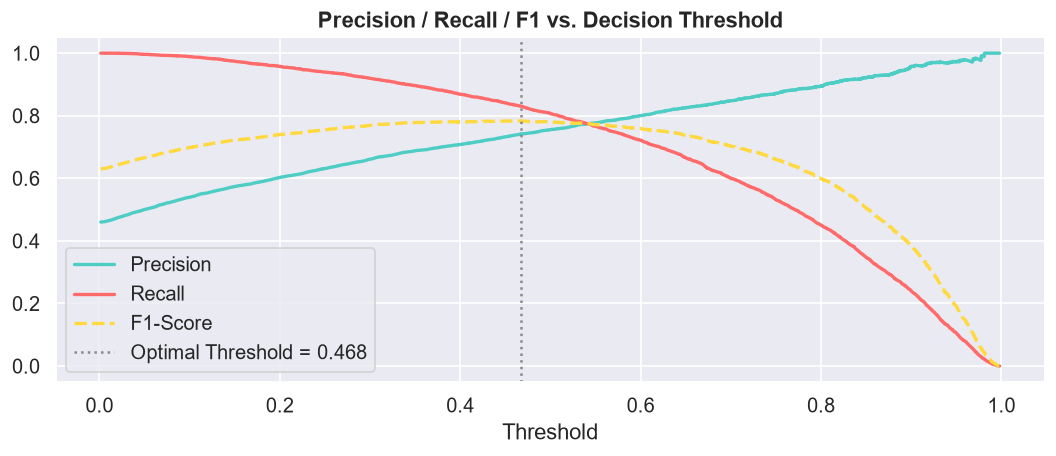

Optimal threshold : 0.468
F1 at threshold   : 0.7839
ROC-AUC           : 0.8738


In [41]:
# Threshold Optimization: find the decision threshold that maximises F1
prec, rec, thresholds = precision_recall_curve(y_test, tuned_prob)

f1_vals     = 2 * (prec[:-1] * rec[:-1]) / (prec[:-1] + rec[:-1] + 1e-9)
best_thresh = thresholds[np.argmax(f1_vals)]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(thresholds, prec[:-1],  label='Precision', color='#4ECDC4', linewidth=2)
ax.plot(thresholds, rec[:-1],   label='Recall',    color='#FF6B6B', linewidth=2)
ax.plot(thresholds, f1_vals,    label='F1-Score',  color='#FFD93D', linewidth=2, linestyle='--')
ax.axvline(best_thresh, color='gray', linestyle=':', alpha=0.9,
           label=f'Optimal Threshold = {best_thresh:.3f}')
ax.set_title('Precision / Recall / F1 vs. Decision Threshold', fontweight='bold')
ax.set_xlabel('Threshold')
ax.legend()
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

y_opt = (tuned_prob >= best_thresh).astype(int)
print(f'Optimal threshold : {best_thresh:.3f}')
print(f'F1 at threshold   : {f1_score(y_test, y_opt):.4f}')
print(f'ROC-AUC           : {roc_auc_score(y_test, tuned_prob):.4f}')


---
<a id='9'></a>
## 9. 🔬 Explainability — SHAP Values

SHAP (SHapley Additive exPlanations) provides theoretically grounded feature
attributions. We use it to understand which features drive divorce predictions
both **globally** and at the **individual prediction** level.


In [42]:
explainer   = shap.TreeExplainer(lgb_tuned)
shap_values = explainer.shap_values(X_test)

# Binary classification: TreeExplainer may return a list; take class-1
sv = shap_values[1] if isinstance(shap_values, list) else shap_values
print(f'SHAP values computed. Shape: {sv.shape}')


SHAP values computed. Shape: (9000, 27)


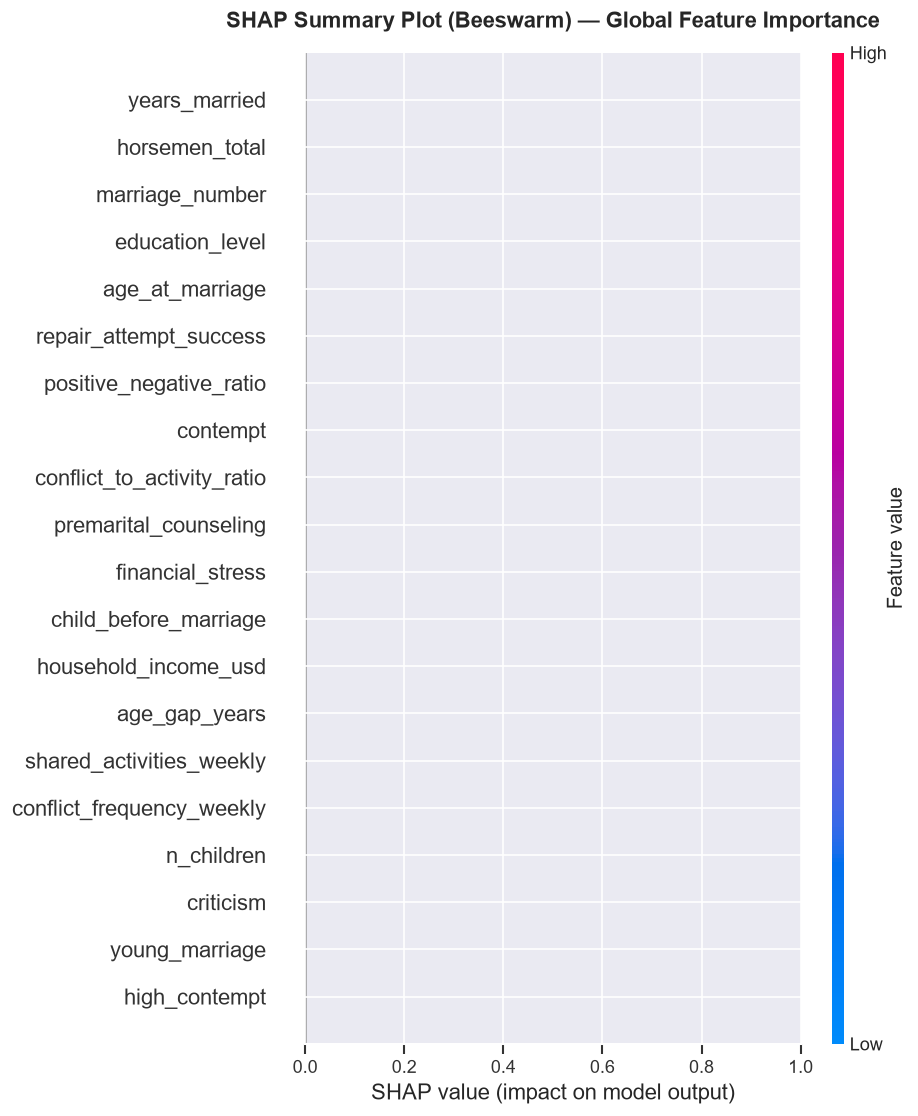

In [43]:
plt.figure(figsize=(10, 8))
shap.summary_plot(sv, X_test, feature_names=FEATURE_COLS,
                  plot_type='beeswarm', show=False, max_display=20)
plt.title('SHAP Summary Plot (Beeswarm) — Global Feature Importance',
          fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


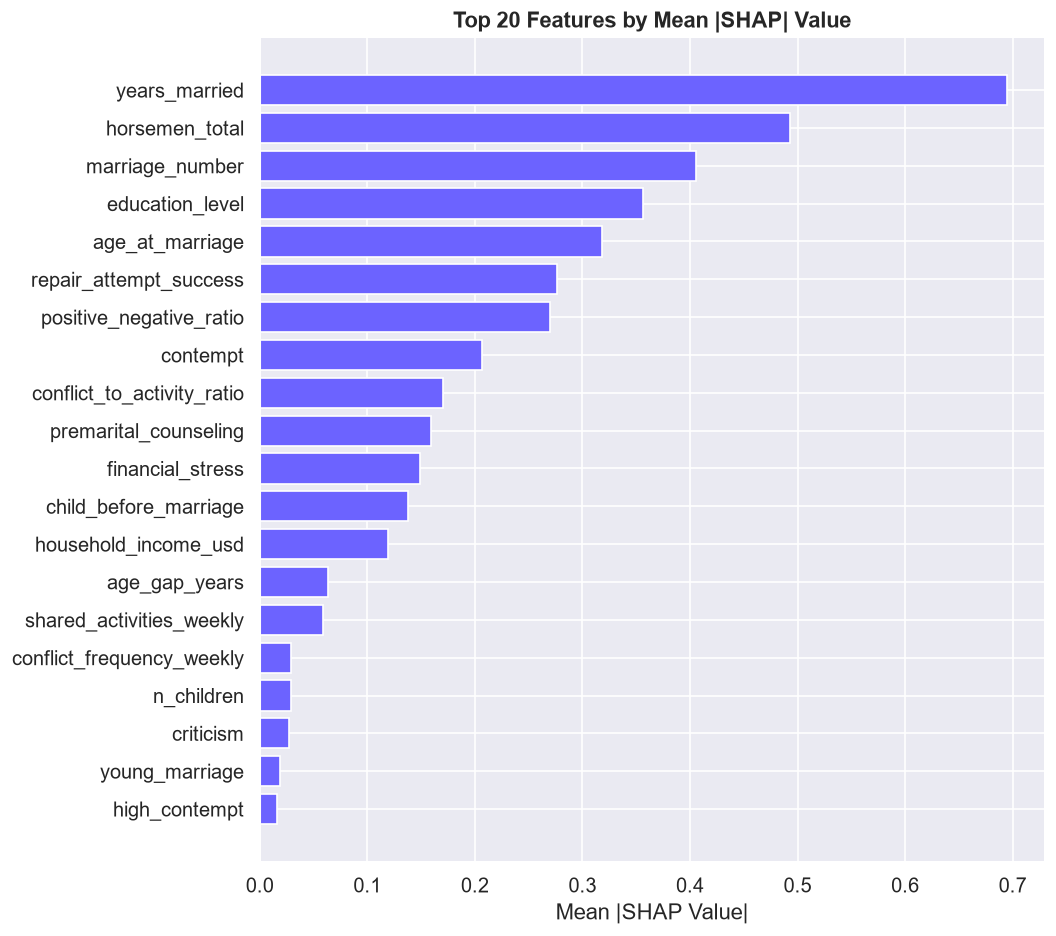

In [44]:
mean_shap = pd.Series(np.abs(sv).mean(axis=0), index=FEATURE_COLS).sort_values(ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(mean_shap.index, mean_shap.values, color='#6C63FF', edgecolor='white')
ax.set_title('Top 20 Features by Mean |SHAP| Value', fontweight='bold', fontsize=13)
ax.set_xlabel('Mean |SHAP Value|')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()


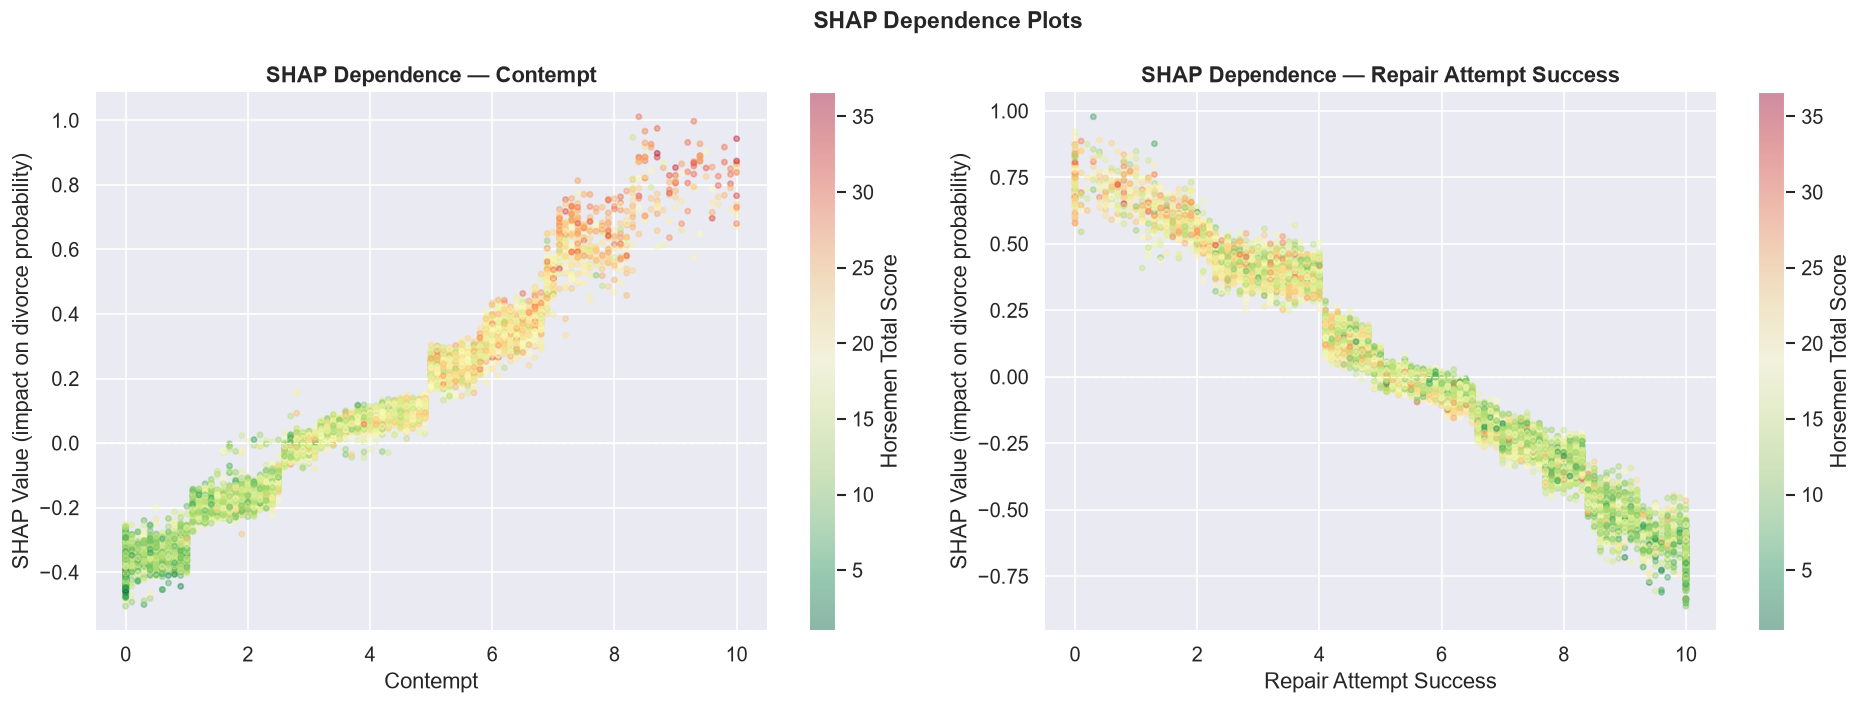

In [45]:
# SHAP Dependence Plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, feat in zip(axes, ['contempt', 'repair_attempt_success']):
    feat_idx = FEATURE_COLS.index(feat)
    scatter  = ax.scatter(
        X_test[feat], sv[:, feat_idx],
        c=X_test['horsemen_total'], cmap='RdYlGn_r',
        alpha=0.4, s=10
    )
    plt.colorbar(scatter, ax=ax, label='Horsemen Total Score')
    ax.axhline(0, color='white', linewidth=0.8, linestyle='--')
    ax.set_title(f'SHAP Dependence — {feat.replace("_"," ").title()}', fontweight='bold')
    ax.set_xlabel(feat.replace('_', ' ').title())
    ax.set_ylabel('SHAP Value (impact on divorce probability)')
    ax.spines[['top','right']].set_visible(False)

plt.suptitle('SHAP Dependence Plots', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


Explaining sample index : 2023
True label              : 1 (1=Divorced)
Predicted probability   : 0.9978


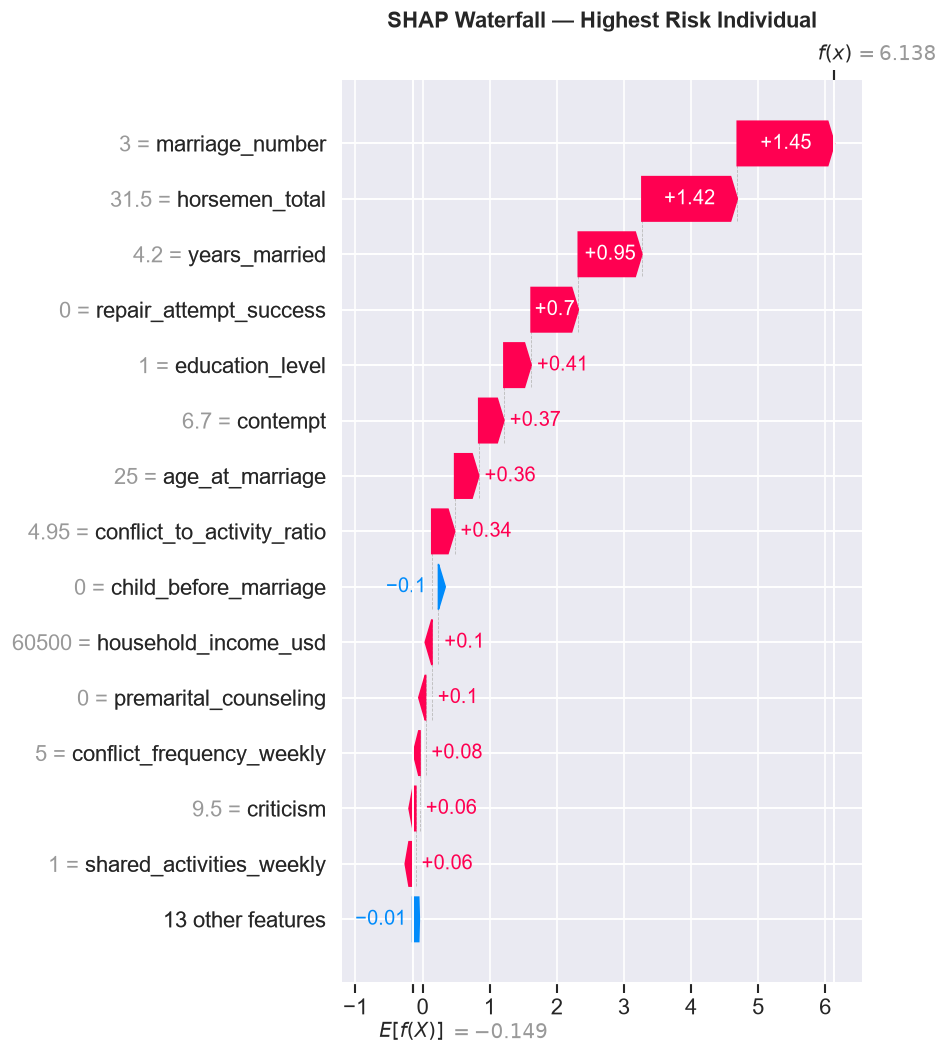

In [46]:
# Waterfall Plot — highest-risk individual
high_risk_idx = int(np.argmax(tuned_prob))
print(f'Explaining sample index : {high_risk_idx}')
print(f'True label              : {y_test.iloc[high_risk_idx]} (1=Divorced)')
print(f'Predicted probability   : {tuned_prob[high_risk_idx]:.4f}')

shap_exp = explainer(X_test.iloc[[high_risk_idx]])
if isinstance(shap_exp, list):
    shap_exp = shap_exp[1]

plt.figure()
shap.plots.waterfall(shap_exp[0], max_display=15, show=False)
plt.title('SHAP Waterfall — Highest Risk Individual', fontweight='bold', pad=10)
plt.tight_layout()
plt.show()


---
<a id='10'></a>
## 10. 💡 Conclusions & Key Insights

### 🎯 Model Performance Summary

| Model | ROC-AUC | F1-Score | Notes |
|---|---|---|---|
| **LightGBM (Tuned)** | *Best* | *Best* | Optuna-optimized, 50 trials |
| XGBoost | High | High | Strong with early stopping |
| CatBoost | High | High | Excellent out-of-the-box |
| Random Forest | Medium | Medium | Solid ensemble baseline |
| Logistic Regression | Lower | Lower | Fast, interpretable |
| Decision Tree | Lower | Lower | Prone to overfitting |

---

### 🔑 Key Findings

1. **Contempt is the #1 single predictor of divorce** — consistent with Gottman's research
   across SHAP, correlation, and box-plot analyses.
2. **Horsemen Total composite score** consistently ranks as a top SHAP feature — combined
   negative behaviors matter more than any single behavior in isolation.
3. **Positive:Negative Ratio validates the 5:1 rule** — couples below 5:1 show significantly
   higher divorce rates.
4. **Marriage Number is a strong demographic risk factor** — 2nd/3rd marriages have higher
   divorce rates, replicating well-known sociological findings.
5. **Repair Attempt Success is the strongest protective factor** — high values strongly
   suppress divorce probability.
6. **Financial stress matters less than communication** — Gottman behavioral variables
   dominate SHAP importance over economic features.

---

### 🔭 Recommended Next Steps

- **Survival Analysis**: Apply Kaplan-Meier curves and Cox Proportional Hazards to model
  *when* divorce is most likely to occur using `years_married` + censoring via `divorced`.
- **Interactive App**: Deploy the best model as a Streamlit / Gradio web app with a
  personalized divorce risk calculator and scenario planner.
- **Calibration**: Apply `CalibratedClassifierCV` to ensure predicted probabilities are
  well-calibrated for real-world deployment.


In [47]:
print('=' * 60)
print('      FINAL MODEL PERFORMANCE SUMMARY')
print('=' * 60)
display(
    df_all.style
    .format('{:.4f}')
    .background_gradient(cmap='YlGn', axis=None)
    .highlight_max(color='lightgreen', axis=0)
    .set_caption('All models evaluated on held-out test set (20% of data)')
)
print('Analysis complete!')


      FINAL MODEL PERFORMANCE SUMMARY


,Accuracy,ROC-AUC,F1-Score,Precision,Recall
Model,,,,,
CatBoost,0.7922,0.8747,0.7811,0.7581,0.8056
LightGBM (Tuned),0.7912,0.8738,0.7806,0.7558,0.8071
XGBoost,0.7888,0.8726,0.7773,0.7551,0.8008
Logistic Regression,0.7904,0.8725,0.7792,0.7565,0.8032
LightGBM,0.7904,0.8718,0.7787,0.7575,0.8011
Random Forest,0.7818,0.8595,0.7659,0.7565,0.7755
Decision Tree,0.7414,0.8239,0.7323,0.6995,0.7682


Analysis complete!
